# REGRESIÓN LOGÍSTICA — EJERCICIO APLICADO

**Predicción de contratación de un depósito a plazo mediante Regresión Logística**

**Estudiante:** Gabriela Suesca Castillo  
**Universidad:** Universidad de Cundinamarca  
**Asignatura:** Introducción a Machine Learning  
**Docente:** Monica Fonseca  
**Fecha:** 3 de octubre de 2026

**Repositorio GitHub:** pegar aquí el enlace cuando se cree el repositorio.

## Objetivo

Construir un modelo de clasificación que estime la probabilidad de que un cliente acepte contratar un depósito a plazo después de una campaña de marketing telefónico.

La variable objetivo es binaria:

- **0 = No**
- **1 = Sí**

El dataset utilizado es **Bank Marketing**, disponible en el UCI Machine Learning Repository. La documentación de UCI define `y` como la variable que indica si el cliente suscribió o no un depósito a plazo.

**Fuente:** Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306


## 1. Planteamiento del problema

### Pregunta de análisis

> ¿Las características del cliente y su interacción con una campaña de marketing permiten estimar la probabilidad de que acepte un depósito a plazo?

### Variable objetivo

`y`

- `no` → 0
- `yes` → 1

### Predictores

Se utilizarán variables demográficas, financieras y relacionadas con la campaña:

- `age`
- `job`
- `marital`
- `education`
- `default`
- `balance`
- `housing`
- `loan`
- `contact`
- `day`
- `month`
- `campaign`
- `pdays`
- `previous`
- `poutcome`

### Criterio de modelamiento

La variable `duration` no se utilizará como predictor. La duración de la llamada ocurre durante el contacto y, si el objetivo es apoyar la decisión antes de cerrar la interacción, usarla puede introducir información que no estaría disponible en el momento de la predicción.


## 2. Instalación y librerías

Esta celda prepara el entorno de Google Colab.


In [1]:
!pip -q install ucimlrepo

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")

## 3. Recolección de datos

Los datos se consultan directamente desde el UCI Machine Learning Repository mediante `ucimlrepo`. Esto deja trazabilidad del origen y hace que el notebook pueda reproducirse.


In [3]:
bank_marketing = fetch_ucirepo(id=222)

X_original = bank_marketing.data.features.copy()
y_original = bank_marketing.data.targets.copy()

df = pd.concat([X_original, y_original], axis=1)

print("Datos descargados correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Datos descargados correctamente
Filas: 45211
Columnas: 17


In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [5]:
print("Nombres de columnas:")
print(df.columns.tolist())

print("\nTamaño del dataset:", df.shape)

Nombres de columnas:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Tamaño del dataset: (45211, 17)


## 4. Revisión de calidad

Primero se revisan tipos de datos, valores faltantes y registros duplicados.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:", df.duplicated().sum())

Valores faltantes por columna:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

Registros duplicados: 0


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,44923,11,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,43354,3,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,32191,2,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


### Distribución de la variable objetivo

Antes de entrenar el modelo es importante comprobar si las clases están balanceadas.


In [9]:
conteo_y = df["y"].value_counts()
porcentaje_y = df["y"].value_counts(normalize=True) * 100

tabla_clases = pd.DataFrame({
    "Conteo": conteo_y,
    "Porcentaje": porcentaje_y.round(2)
})

tabla_clases

,Conteo,Porcentaje
y,,
no,39922,88.3
yes,5289,11.7


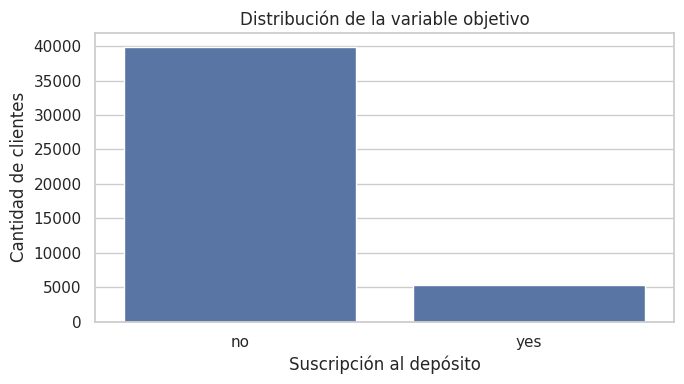

In [10]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="y")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Suscripción al depósito")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

## 5. Preparación de los datos

La variable objetivo se convierte a valores 0 y 1. Para los predictores se separan variables numéricas y categóricas.

El preprocesamiento incluye:

- Imputación de valores numéricos con la mediana.
- Imputación de categóricas con la categoría más frecuente.
- Estandarización de variables numéricas.
- One-hot encoding para variables categóricas.
- Eliminación de la primera categoría de cada variable categórica para trabajar con una categoría de referencia.

Todo se integra en un `Pipeline` para mantener el mismo proceso durante entrenamiento y predicción.


In [16]:
df["y_bin"] = df["y"].map({"no": 0, "yes": 1})

predictores = [
    "age", "job", "marital", "education", "default",
    "balance", "housing", "loan", "contact", "day_of_week",
    "month", "campaign", "pdays", "previous", "poutcome"
]

X = df[predictores].copy()
y = df["y_bin"].copy()

variables_numericas = [
    "age", "balance", "day_of_week", "campaign", "pdays", "previous"
]

variables_categoricas = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome"
]

print("Predictores:", len(predictores))
print("Variables numéricas:", len(variables_numericas))
print("Variables categóricas:", len(variables_categoricas))

Predictores: 15
Variables numéricas: 6
Variables categóricas: 9


## 6. División en entrenamiento y prueba

Se utiliza un 80 % de los datos para entrenamiento y un 20 % para prueba. `stratify=y` conserva aproximadamente la misma proporción de las clases en ambos conjuntos.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (36168, 15)
Prueba: (9043, 15)


## 7. Preprocesamiento + Regresión Logística

Se utiliza regresión logística con regularización L2. La configuración `class_weight="balanced"` compensa el desbalance entre clientes que no contratan y clientes que sí contratan.

El objetivo no es maximizar únicamente accuracy, sino obtener un modelo que también identifique correctamente la clase positiva.


In [18]:
transformaciones_numericas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformaciones_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformaciones_numericas, variables_numericas),
        ("cat", transformaciones_categoricas, variables_categoricas)
    ]
)

modelo = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", modelo)
])

pipeline.fit(X_train, y_train)

probabilidades = pipeline.predict_proba(X_test)[:, 1]
predicciones_05 = (probabilidades >= 0.50).astype(int)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## 8. Evaluación con umbral 0,50

El umbral 0,50 es una referencia inicial: si la probabilidad estimada es mayor o igual a 0,50 se asigna la clase 1.


In [19]:
metricas_05 = {
    "Accuracy": accuracy_score(y_test, predicciones_05),
    "Precision": precision_score(y_test, predicciones_05, zero_division=0),
    "Recall": recall_score(y_test, predicciones_05, zero_division=0),
    "F1": f1_score(y_test, predicciones_05, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, probabilidades),
    "PR-AUC": average_precision_score(y_test, probabilidades)
}

metricas_05_df = pd.DataFrame({
    "Métrica": list(metricas_05.keys()),
    "Resultado": list(metricas_05.values())
})

metricas_05_df["Resultado"] = metricas_05_df["Resultado"].round(4)

metricas_05_df

,Métrica,Resultado
0,Accuracy,0.7622
1,Precision,0.2684
2,Recall,0.5983
3,F1,0.3706
4,ROC-AUC,0.7518
5,PR-AUC,0.3935


In [20]:
print(classification_report(
    y_test,
    predicciones_05,
    target_names=["No", "Sí"],
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

          No     0.9364    0.7840    0.8534      7985
          Sí     0.2684    0.5983    0.3706      1058

    accuracy                         0.7622      9043
   macro avg     0.6024    0.6911    0.6120      9043
weighted avg     0.8583    0.7622    0.7970      9043



## 9. Matriz de confusión

La matriz permite observar aciertos y errores por clase:

- Verdaderos negativos
- Falsos positivos
- Falsos negativos
- Verdaderos positivos


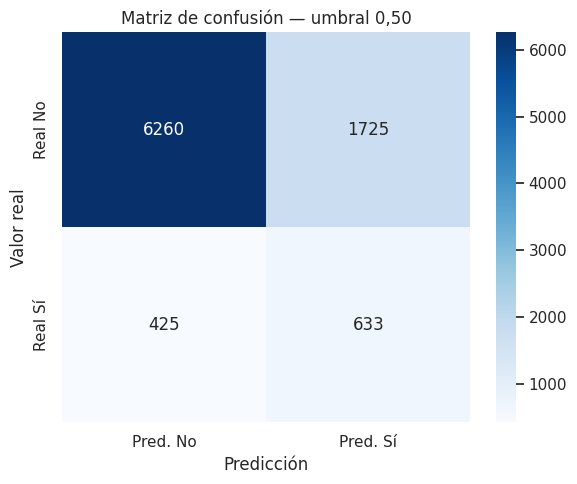

In [21]:
cm = confusion_matrix(y_test, predicciones_05)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred. No", "Pred. Sí"],
    yticklabels=["Real No", "Real Sí"]
)

plt.title("Matriz de confusión — umbral 0,50")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

## 10. Curva ROC

La curva ROC relaciona sensibilidad y tasa de falsos positivos para diferentes umbrales.


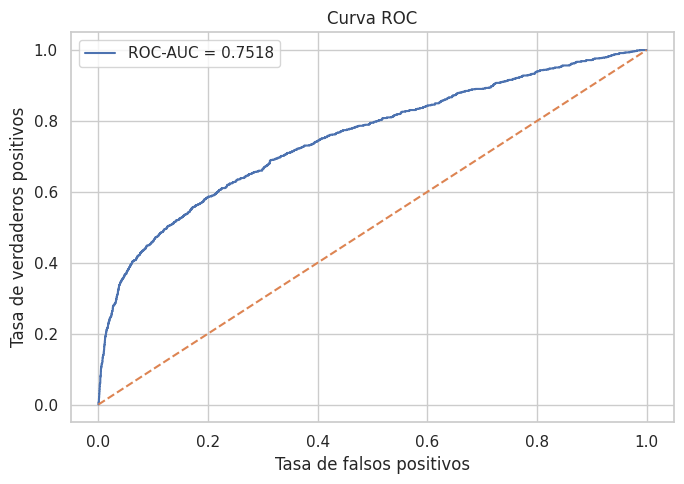

In [22]:
fpr, tpr, _ = roc_curve(y_test, probabilidades)

auc_roc = roc_auc_score(y_test, probabilidades)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_roc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Curva Precision-Recall

Esta curva es útil cuando las clases están desbalanceadas porque permite observar precision y recall para diferentes umbrales.


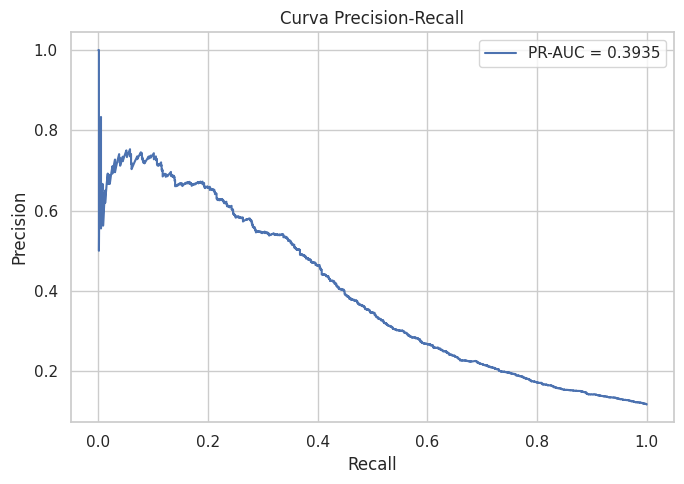

In [23]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    y_test,
    probabilidades
)

pr_auc = average_precision_score(y_test, probabilidades)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_vals,
    precision_vals,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Ajuste del umbral de decisión

El valor 0,50 no siempre es el más conveniente. En esta sección se prueban diferentes umbrales y se selecciona el que produce el mayor F1 dentro del rango evaluado.

El umbral seleccionado no reemplaza el criterio del negocio; sirve como una comparación técnica.


In [24]:
umbrales = np.arange(0.10, 0.91, 0.01)

resultados_umbral = []

for umbral in umbrales:
    pred = (probabilidades >= umbral).astype(int)

    resultados_umbral.append({
        "Umbral": umbral,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Accuracy": accuracy_score(y_test, pred)
    })

tabla_umbral = pd.DataFrame(resultados_umbral)

mejor_f1 = tabla_umbral.loc[
    tabla_umbral["F1"].idxmax()
]

mejor_f1

,55
Umbral,0.650000
Precision,0.458647
Recall,0.403592
F1,0.429361
Accuracy,0.874489


In [25]:
umbral_optimo = float(mejor_f1["Umbral"])

predicciones_opt = (
    probabilidades >= umbral_optimo
).astype(int)

metricas_opt = {
    "Accuracy": accuracy_score(y_test, predicciones_opt),
    "Precision": precision_score(y_test, predicciones_opt, zero_division=0),
    "Recall": recall_score(y_test, predicciones_opt, zero_division=0),
    "F1": f1_score(y_test, predicciones_opt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, probabilidades),
    "PR-AUC": average_precision_score(y_test, probabilidades)
}

comparacion_metricas = pd.DataFrame({
    "Métrica": list(metricas_05.keys()),
    "Umbral 0.50": list(metricas_05.values()),
    "Umbral óptimo": list(metricas_opt.values())
})

comparacion_metricas["Umbral 0.50"] = comparacion_metricas["Umbral 0.50"].round(4)
comparacion_metricas["Umbral óptimo"] = comparacion_metricas["Umbral óptimo"].round(4)

print("Umbral seleccionado:", round(umbral_optimo, 2))
comparacion_metricas

Umbral seleccionado: 0.65


,Métrica,Umbral 0.50,Umbral óptimo
0,Accuracy,0.7622,0.8745
1,Precision,0.2684,0.4586
2,Recall,0.5983,0.4036
3,F1,0.3706,0.4294
4,ROC-AUC,0.7518,0.7518
5,PR-AUC,0.3935,0.3935


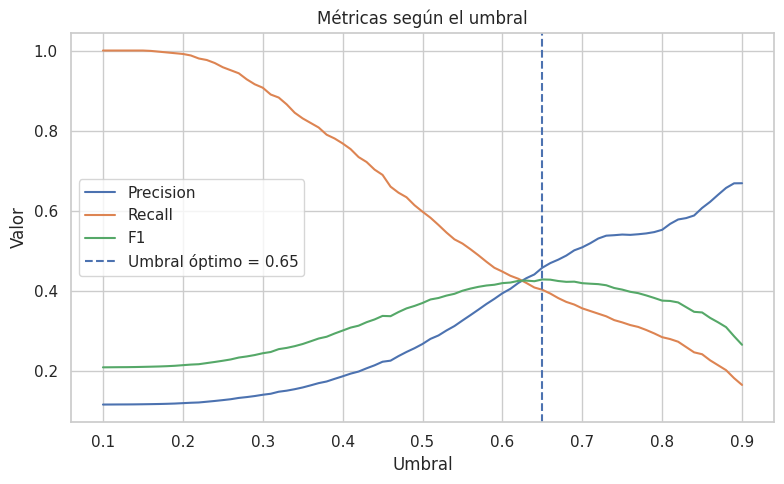

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla_umbral["Umbral"],
    tabla_umbral["Precision"],
    label="Precision"
)

plt.plot(
    tabla_umbral["Umbral"],
    tabla_umbral["Recall"],
    label="Recall"
)

plt.plot(
    tabla_umbral["Umbral"],
    tabla_umbral["F1"],
    label="F1"
)

plt.axvline(
    umbral_optimo,
    linestyle="--",
    label=f"Umbral óptimo = {umbral_optimo:.2f}"
)

plt.title("Métricas según el umbral")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Interpretabilidad: coeficientes y odds ratios

En regresión logística, cada coeficiente indica cómo cambia el log-odds al variar el predictor.

Para facilitar la interpretación se transforma cada coeficiente con:

**Odds ratio = e^(coeficiente)**

Como se utilizó `drop="first"` en variables categóricas, cada categoría se compara con una categoría de referencia.


In [27]:
modelo_final = pipeline.named_steps["model"]
preprocesador_final = pipeline.named_steps["preprocessor"]

nombres_variables = preprocesador_final.get_feature_names_out()
coeficientes = modelo_final.coef_[0]

odds_ratios = np.exp(coeficientes)

tabla_or = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes,
    "Odds_Ratio": odds_ratios
})

tabla_or["Abs_Coef"] = tabla_or["Coeficiente"].abs()

tabla_or = tabla_or.sort_values(
    "Abs_Coef",
    ascending=False
).drop(columns="Abs_Coef")

tabla_or.head(20)

,Variable,Coeficiente,Odds_Ratio
36,cat__poutcome_success,2.329740,10.275274
30,cat__month_mar,1.103041,3.013316
27,cat__month_jan,-1.088135,0.336844
31,cat__month_may,-0.963980,0.381372
32,cat__month_nov,-0.842911,0.430456
24,cat__month_aug,-0.787554,0.454956
33,cat__month_oct,0.759639,2.137504
25,cat__month_dec,0.755491,2.128657
29,cat__month_jun,-0.710217,0.491537
28,cat__month_jul,-0.621764,0.536996


In [28]:
tabla_or["Interpretacion"] = np.where(
    tabla_or["Odds_Ratio"] > 1,
    "Aumenta los odds de clase 1",
    "Disminuye los odds de clase 1"
)

tabla_or.head(20)

,Variable,Coeficiente,Odds_Ratio,Interpretacion
36,cat__poutcome_success,2.329740,10.275274,Aumenta los odds de clase 1
30,cat__month_mar,1.103041,3.013316,Aumenta los odds de clase 1
27,cat__month_jan,-1.088135,0.336844,Disminuye los odds de clase 1
31,cat__month_may,-0.963980,0.381372,Disminuye los odds de clase 1
32,cat__month_nov,-0.842911,0.430456,Disminuye los odds de clase 1
24,cat__month_aug,-0.787554,0.454956,Disminuye los odds de clase 1
33,cat__month_oct,0.759639,2.137504,Aumenta los odds de clase 1
25,cat__month_dec,0.755491,2.128657,Aumenta los odds de clase 1
29,cat__month_jun,-0.710217,0.491537,Disminuye los odds de clase 1
28,cat__month_jul,-0.621764,0.536996,Disminuye los odds de clase 1


## 14. Revisión rápida de probabilidades

La regresión logística no solamente entrega una clase. También entrega una probabilidad, que posteriormente puede convertirse en una decisión usando un umbral.


In [29]:
muestra_probabilidades = X_test.copy()
muestra_probabilidades["Probabilidad_Si"] = probabilidades
muestra_probabilidades["Clase_real"] = y_test.values
muestra_probabilidades["Prediccion_0_50"] = predicciones_05

muestra_probabilidades[
    ["Probabilidad_Si", "Clase_real", "Prediccion_0_50"]
].head(15)

,Probabilidad_Si,Clase_real,Prediccion_0_50
1392,0.173444,0,0
7518,0.243941,0,0
12007,0.261637,0,0
5536,0.196585,0,0
29816,0.508235,0,1
18275,0.271186,0,0
8543,0.478087,0,0
43965,0.945799,1,1
28083,0.432566,0,0
25787,0.468351,0,0


## 15. Conclusiones

Complete estas ideas con los valores que aparezcan al ejecutar el notebook:

1. El modelo permitió estimar la probabilidad de contratación de un depósito a plazo a partir de variables del cliente y de la campaña.
2. La evaluación debe considerar precision, recall y F1 además de accuracy, especialmente después de revisar la distribución de las clases.
3. ROC-AUC y PR-AUC permiten valorar el comportamiento del modelo sin depender de un único umbral.
4. El ajuste del umbral muestra que la decisión de clasificar como cliente potencial puede cambiar según el equilibrio deseado entre falsos positivos y falsos negativos.
5. Los odds ratios facilitan la interpretación de cómo cada variable se relaciona con la probabilidad de la clase positiva.
6. Como limitación, el modelo depende de las variables disponibles en este dataset y de la calidad y representatividad de los datos. Además, se excluyó `duration` para evitar utilizar información de la llamada que puede no estar disponible al momento de decidir a quién dirigir la acción comercial.


## 16. Exportación de resultados

Las siguientes celdas guardan tablas que pueden utilizarse posteriormente en el informe.


In [30]:
metricas_05_df.to_csv("metricas_umbral_050.csv", index=False)
comparacion_metricas.to_csv("comparacion_umbral.csv", index=False)
tabla_or.to_csv("odds_ratios_regresion_logistica.csv", index=False)
df.to_csv("bank_marketing_completo.csv", index=False)

print("Archivos exportados correctamente")

Archivos exportados correctamente


## 17. Referencia del dataset

Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306

La ficha de UCI describe este conjunto como un problema de clasificación relacionado con campañas de marketing telefónico de una institución bancaria portuguesa. La variable objetivo `y` indica si el cliente suscribió o no un depósito a plazo.

**Enlace del dataset:**  
https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing
